In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import seaborn as sns

from network_original_lpn import LPN
from network_ne_by_norm import NE_LPN_By_Norm
from network_scale_equiv_by_design import Scale_LPN_By_Design
from utils import prox, cvx, prior, gt_cvx_split_normal, split_normal_log_prior, prox_split_normal

MODEL_DIR = "experiments/models/"
PLOT_DIR = "experiments/plots/"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
sns.set()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

np.random.seed(1)
torch.manual_seed(1)

In [2]:
class NormalSampler:
    def __init__(self, mean=0.0, std=1.0):
        self.mean = mean
        self.std = std

    def __call__(self, n):
        return torch.randn(n) * self.std + self.mean

def add_noise(x, sigma=0.1):
    return x + torch.randn_like(x) * sigma

def exp_func(x, gamma):
    return -torch.exp(-((x / gamma) ** 2)) + 1

In [3]:
class SplitNormalSampler:
    def __init__(self, mean: float = 0.0, std_left: float = 1.0, std_right: float = 2.0):
        self.mean = mean
        self.std_left = std_left
        self.std_right = std_right
        self.p_left = std_left / (std_left + std_right)

    def __call__(self, n: int):
        u = torch.rand(n)
        z = torch.randn(n).abs()
        samples = torch.where(
            u < self.p_left,
            self.mean - z * self.std_left,
            self.mean + z * self.std_right
        )
        return samples

In [4]:
def single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss=None):
    target = sampler(bsize).unsqueeze(1).to(device)
    input_ = add_noise(target, sigma_noise).to(device)
    output = model(input_)

    if loss_type == 2:
        loss = torch.nn.functional.mse_loss(output, target)
    elif loss_type == 1:
        loss = torch.nn.functional.l1_loss(output, target)
    elif loss_type == 0:
        loss = exp_func(output - target, gamma_loss).mean()
    else:
        raise ValueError("Invalid loss_type")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if hasattr(model, "wclip"):
        model.wclip()
    return loss.item()


In [5]:
def plot_all(model, title, mean=0.0, stdev_right=2.0, stdev_left=1.0):
    xi = np.linspace(-8, 8, 1000)
    y = prox(xi, model)
    c = cvx(xi, model)
    p = prior(xi, model)

    fig, axs = plt.subplots(1, 3, figsize=(8, 3))
    axs[0].plot(xi, y, label="LPN")
    axs[0].plot(xi, prox_split_normal(xi), '--', label="split normal prox")
    axs[0].set_title("Learned prox")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(xi, c - c.min(), label="Cvx func")
    axs[1].plot(xi, gt_cvx_split_normal(xi), '--', label="ref.")
    axs[1].set_title("Cvx func")
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(xi, p - p.min(), label="LPN")
    axs[2].plot(xi, split_normal_log_prior(xi, mean, stdev_left, stdev_right), '--', label="split normal log-prior")
    axs[2].set_title("Original func")
    axs[2].grid(True)
    axs[2].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{title}_plot.png"))
    plt.show()

In [6]:
def plot_comparison(models, mean=0.0, stdev_right=2.0, stdev_left=1.0):
    xi = np.linspace(-8, 8, 1000)

    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2])

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])

    for name, model in models.items():
        y = prox(xi, model)
        c = cvx(xi, model)
        p = prior(xi, model)

        ax1.plot(xi, y, label=name)
        ax2.plot(xi, c - c.min(), label=name)
        ax3.plot(xi, p - p.min(), label=name)

    ax1.plot(xi, prox_split_normal(xi), '--', label=r"$\mathcal{SN}(0,1,2)$ proximal operator")
    ax1.set_title(r"Learned proximal $\nabla f_\theta$")

    ax2.plot(xi, gt_cvx_split_normal(xi), '--', label="Reference")
    ax2.set_title(r"Convex function $f_\theta$")

    ax3.plot(xi, split_normal_log_prior(xi, mean, stdev_left, stdev_right), '--', 
             label=r"$\mathcal{SN}(0,1,2)$ log-prior")
    ax3.set_title(r"Log-prior $R_\theta$")  

    for ax in [ax1, ax2, ax3]:
        ax.grid(True)
        ax.legend()

    plt.suptitle("Model Comparison")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(os.path.join(PLOT_DIR, "model_comparison_square.png"))
    plt.show()

In [7]:
def train_model(model, model_name, loss_type, gamma_loss, sampler, sigma_noise, 
                lr_schedule, iterations_per_phase):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_schedule[0])
    bsize = 2000
    loss_log = []

    print(f"Training {model_name}...")
    for phase, lr in enumerate(lr_schedule):
        for g in optimizer.param_groups:
            g['lr'] = lr
        for i in range(iterations_per_phase):
            loss = single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss)
            if i % 100 == 0:
                print(f"{model_name} | Phase {phase+1}/{len(lr_schedule)} | Iter {i}: Loss = {loss:.6f}")
                loss_log.append(loss)

    # Save and plot
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pth")
    torch.save(model.state_dict(), model_path)
    plot_all(model, title=model_name)
    return model
    

In [8]:
mean, std_left, std_right = 0.0, 1.0, 2.0
sampler = SplitNormalSampler(mean=mean, std_left=std_left, std_right=std_right) 
sigma_noise = 1.0
loss_type = 0
gamma_loss = 0.1
lr_schedule = [1e-3, 1e-4]
iterations_per_phase = 10000

In [9]:
dim = 1
hidden = 50
layers = 4
beta = 10

In [10]:
def get_models():
    return {
        "Equivariant by Design": Scale_LPN_By_Design(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "Equivariant by Normalization Trick": NE_LPN_By_Norm(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "Original LPN": LPN(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
    }

Training Equivariant by Design...
Equivariant by Design | Phase 1/2 | Iter 0: Loss = 0.984173
Equivariant by Design | Phase 1/2 | Iter 100: Loss = 0.998501
Equivariant by Design | Phase 1/2 | Iter 200: Loss = 0.993378
Equivariant by Design | Phase 1/2 | Iter 300: Loss = 0.997205
Equivariant by Design | Phase 1/2 | Iter 400: Loss = 0.993027
Equivariant by Design | Phase 1/2 | Iter 500: Loss = 0.940495
Equivariant by Design | Phase 1/2 | Iter 600: Loss = 0.941995
Equivariant by Design | Phase 1/2 | Iter 700: Loss = 0.931996
Equivariant by Design | Phase 1/2 | Iter 800: Loss = 0.932602
Equivariant by Design | Phase 1/2 | Iter 900: Loss = 0.945175
Equivariant by Design | Phase 1/2 | Iter 1000: Loss = 0.921434
Equivariant by Design | Phase 1/2 | Iter 1100: Loss = 0.928316
Equivariant by Design | Phase 1/2 | Iter 1200: Loss = 0.928466
Equivariant by Design | Phase 1/2 | Iter 1300: Loss = 0.927449
Equivariant by Design | Phase 1/2 | Iter 1400: Loss = 0.928319
Equivariant by Design | Phase 1/2

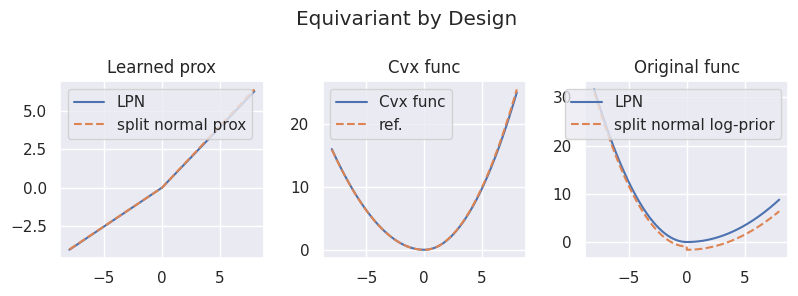

Training Equivariant by Normalization Trick...
Equivariant by Normalization Trick | Phase 1/2 | Iter 0: Loss = 0.945514
Equivariant by Normalization Trick | Phase 1/2 | Iter 100: Loss = 0.909060
Equivariant by Normalization Trick | Phase 1/2 | Iter 200: Loss = 0.921560
Equivariant by Normalization Trick | Phase 1/2 | Iter 300: Loss = 0.918375
Equivariant by Normalization Trick | Phase 1/2 | Iter 400: Loss = 0.919159
Equivariant by Normalization Trick | Phase 1/2 | Iter 500: Loss = 0.912398
Equivariant by Normalization Trick | Phase 1/2 | Iter 600: Loss = 0.912217
Equivariant by Normalization Trick | Phase 1/2 | Iter 700: Loss = 0.919446
Equivariant by Normalization Trick | Phase 1/2 | Iter 800: Loss = 0.916457
Equivariant by Normalization Trick | Phase 1/2 | Iter 900: Loss = 0.914469
Equivariant by Normalization Trick | Phase 1/2 | Iter 1000: Loss = 0.918389
Equivariant by Normalization Trick | Phase 1/2 | Iter 1100: Loss = 0.903475
Equivariant by Normalization Trick | Phase 1/2 | Iter

KeyboardInterrupt: 

In [11]:
trained_models = {}
for name, model in get_models().items():
    trained_models[name] = train_model(model, name, loss_type, gamma_loss, 
                                       sampler=sampler, sigma_noise=sigma_noise, 
                                       lr_schedule=lr_schedule, iterations_per_phase=iterations_per_phase)

mse 21.382122039794922


mse 16.793540954589844
mse 13.249153137207031
mse 10.387890815734863
mse 8.084054946899414
mse 6.246293067932129
mse 4.794551849365234
mse 3.6584503650665283
mse 2.776390790939331
mse 2.095982074737549
mse 1.5739675760269165
mse 1.1754366159439087
mse 0.8726250529289246
mse 0.6436582207679749
mse 0.47141125798225403
mse 0.3425477147102356
mse 0.24672946333885193
mse 0.17597395181655884
mse 0.12413807213306427
mse 0.08650804311037064
mse 0.05947604030370712
mse 0.040288787335157394
mse 0.026853317394852638
mse 0.0175870880484581
mse 0.011302756145596504
mse 0.00711837038397789
mse 0.004387252498418093
mse 0.0026425702963024378
mse 0.0015533894766122103
mse 0.000889893970452249
mse 0.0004960941732861102
mse 0.0002687219821382314
mse 0.00014121067943051457
mse 7.186768198153004e-05
mse 3.536355870892294e-05
mse 1.6792158930911683e-05
mse 7.680525413888972e-06
mse 3.3767828426789492e-06
mse 1.4240042673918651e-06
mse 5.746575197917991e-07
mse 2.2161498236528132e-07
mse 8.134817619520618e-0

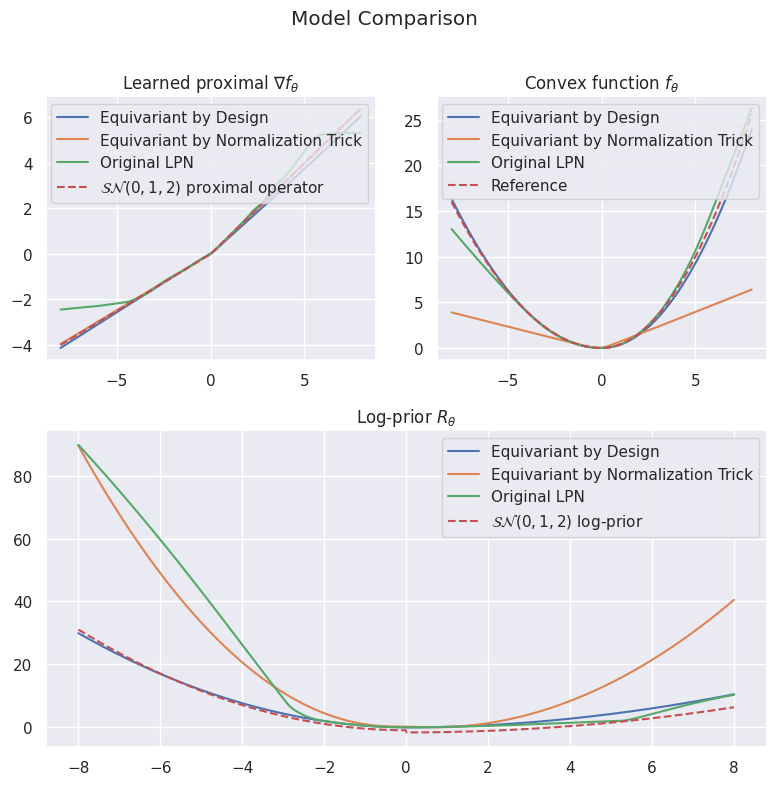

All models trained and plotted.


In [ ]:
plot_comparison(trained_models)
print("All models trained and plotted.")